<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo Semanal Nº8
#### Federico Borello

### Consigna

Dado el siguiente diagrama en bloques:

<div align=center>

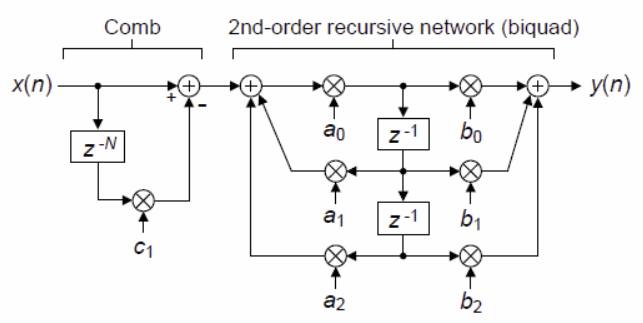

</div>


1. Comprobar que el esquema se corresponde con la siguiente transferencia:
   
   $$H(z) = (1 - c_1\,z^{-N})\;\frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{a_0 - a_1 z^{-1} - a_2 z^{-2}}$$

2. Filtro de media móvil (moving average o CIC: cascaded integrator–comb)
   - Verificar la transferencia para $a_0 = 1,\; a_1 = 1,\; b_0 = 1/N,\; c_1 = 1$ y $N = 3,4,5$.
   - ¿Es un filtro IIR o FIR? Discutir las ventajas que tendría esta implementación respecto al filtro FIR de media móvil de orden 3.
   - ¿Podría implementar el siguiente sistema $h(k) = (1,1,1,1,1,1)$ con esta topología?

3. Filtro diferenciador (differentiator)
   - Obtener los valores de $a_i$ y $b_k$ para obtener
     $$y(n) = \frac{x(n) - x(n-2)}{2}$$
   - Evaluar el sistema con un seno discreto en Python y comprobar si la salida se aproxima a la derivada.

4. Filtro elimina continua (DC Blocker)
   - Verificar la transferencia para $a_0 = 1,\; a_1 = \beta,\; b_0 = 1,\; b_1 = -1$ con $\beta = 0.9$.
   - Determinar $\beta$ para que la ganancia en $\Omega = 0.1\pi$ sea 3 dB menor que la ganancia en $\Omega = \pi$.

5. Filtro peine (Comb filter)
   - Verificar la transferencia para $c_1 = -1$ y $N = 8$.
   - Proponer una $f_{sampling}$ y hallar las frecuencias donde se generan los picos y los nulos en el espectro.

Importante: para los incisos calcular y representar sus singularidades en el plano $z$, la respuesta de módulo y fase de $H(z)$ y su diagrama en bloques. Cuando no se indique, considerar los coeficientes iguales a cero.

Bonus
- Verificar en Python el punto 3 con la función `diff`.
- Utilizando solo el biquad, hallar los valores de los coeficientes para emular la respuesta analógica de un pasabajos de orden 1. Utilice alguno de los métodos de diseño vistos en clase.

In [1]:
from IPython.display import HTML

file = "./TS8_handwritten.pdf"
html = f"""
<div style="text-align:center;">
    <iframe src="{file}" width="900" height="600"></iframe>
</div>
"""
HTML(html)

In [2]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))

# Import common packages
from IPython.display import display, Markdown
import sympy as sp
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import scipy.fftpack as fftpack

## Ejercicio 2 - Filtro de Media Móvil CIC

In [3]:
z = sp.symbols("z", complex=True)
a0, a1, a2, b0, b1, b2 = sp.symbols("a_0 a_1 a_2 b_0 b_1 b_2", real=True)
c1, N, n = sp.symbols("c_1 N n", real=True)

H_biquad = (b0 + b1 * z**-1 + b2 * z**-2) / (1 / a0 - a1 * z**-1 - a2 * z**-2)
H2_tot = (1 - c1 * z**-N) * H_biquad


H2_tot_subs = (
    H2_tot.subs(b0, 1 / N)
    .subs(a0, 1)
    .subs(a1, 1)
    .subs(a2, 0)
    .subs(b1, 0)
    .subs(b2, 0)
    .subs(c1, 1)
)

sum_expr = 1 / N * sp.summation(z**-n, (n, 0, N - 1))

H2_3 = H2_tot_subs.subs(N, 3).simplify()
H2_4 = H2_tot_subs.subs(N, 4).simplify()
H2_5 = H2_tot_subs.subs(N, 5).simplify()

markdown_msg = f"""
### Expresión simbólica
$$H(z) = {sp.latex(H2_tot)}$$
### Puede ser simplificado a:
$$H(z) = {sp.latex(H2_tot_subs)} = \\frac{1}{N}\\sum_{{n=0}}^{{N-1}} z^{{-n}}$$
### Para N = 3, 4, 5 y comparando con la sumatoria:
- N = 3: $$H(z) = {sp.latex(H2_3)} \equiv {sp.latex(sum_expr.subs(N, 3).simplify())}$$
- N = 4: $$H(z) = {sp.latex(H2_4)} \equiv {sp.latex(sum_expr.subs(N, 4).simplify())}$$
- N = 5: $$H(z) = {sp.latex(H2_5)} \equiv {sp.latex(sum_expr.subs(N, 5).simplify())}$$
### ¿Qué tipo de filtro es?
Matematicamente es un filtro FIR debido a la ausencia de polos (denominador = 1). Sumatoria finita de términos.
No obstante, la implementación tiene una realimentación implicita (por el biquad), lo que lo hace confudir con un filtro IIR.
En la práctica, algunas implementaciones pueden presentar inestabilidades o comportamientos no ideales.
Algunas arquitecturas de hardware pueden tener limitaciones en la precisión numérica, lo que puede afectar la estabilidad del filtro.

El FIR puro es inherentemente estable, siendo computacionalmente más simple y eficiente.
En el caso de $N = 3$, habría que hacer 3 sumas y una multiplicación por $1/3$. Si N es multiplo de 2, se puede utiliza un shift.

Si el sistema fuera $h(k) = (1, 1, 1, 1, 1, 1, 1)$ se puede implementar con el diagrama en cascada de un biquad y un comb (N=7) solo si se agrega un
multiplicador por $7$ para compensar la atenuación del biquad (término $b_0 = \\frac{{1}}{{N}}$).
"""
display(Markdown(markdown_msg))


### Expresión simbólica
$$H(z) = \frac{\left(- c_{1} z^{- N} + 1\right) \left(b_{0} + \frac{b_{1}}{z} + \frac{b_{2}}{z^{2}}\right)}{- \frac{a_{1}}{z} - \frac{a_{2}}{z^{2}} + \frac{1}{a_{0}}}$$
### Puede ser simplificado a:
$$H(z) = \frac{1 - z^{- N}}{N \left(1 - \frac{1}{z}\right)} = \frac1N\sum_{n=0}^{N-1} z^{-n}$$
### Para N = 3, 4, 5 y comparando con la sumatoria:
- N = 3: $$H(z) = \frac{z^{2} + z + 1}{3 z^{2}} \equiv \frac{z^{2} + z + 1}{3 z^{2}}$$
- N = 4: $$H(z) = \frac{z^{4} - 1}{4 z^{3} \left(z - 1\right)} \equiv \begin{cases} 1 & \text{for}\: \frac{1}{z} = 1 \\\frac{z^{4} - 1}{4 z^{3} \left(z - 1\right)} & \text{otherwise} \end{cases}$$
- N = 5: $$H(z) = \frac{z^{5} - 1}{5 z^{4} \left(z - 1\right)} \equiv \begin{cases} 1 & \text{for}\: \frac{1}{z} = 1 \\\frac{z^{5} - 1}{5 z^{4} \left(z - 1\right)} & \text{otherwise} \end{cases}$$
### ¿Qué tipo de filtro es?
Matematicamente es un filtro FIR debido a la ausencia de polos (denominador = 1). Sumatoria finita de términos.
No obstante, la implementación tiene una realimentación implicita (por el biquad), lo que lo hace confudir con un filtro IIR.
En la práctica, algunas implementaciones pueden presentar inestabilidades o comportamientos no ideales.
Algunas arquitecturas de hardware pueden tener limitaciones en la precisión numérica, lo que puede afectar la estabilidad del filtro.

El FIR puro es inherentemente estable, siendo computacionalmente más simple y eficiente.
En el caso de $N = 3$, habría que hacer 3 sumas y una multiplicación por $1/3$. Si N es multiplo de 2, se puede utiliza un shift.

Si el sistema fuera $h(k) = (1, 1, 1, 1, 1, 1, 1)$ se puede implementar con el diagrama en cascada de un biquad y un comb (N=7) solo si se agrega un
multiplicador por $7$ para compensar la atenuación del biquad (término $b_0 = \frac{1}{N}$).


In [4]:
# Funciones de utilidad
def zplane(b, a, ax=None, title=None):
    """Plot zeros and poles on the z-plane."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    # compute roots
    zzeros = np.roots(b) if len(b) > 1 else np.array([])
    zpoles = np.roots(a) if len(a) > 1 else np.array([])
    print("Zeros:", zzeros)
    print("Poles:", zpoles)
    # unit circle
    theta = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=0.8)
    # axes
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)
    # plot zeros and poles
    if zzeros.size:
        ax.scatter(
            zzeros.real,
            zzeros.imag,
            marker="o",
            facecolors="none",
            edgecolors="b",
            s=80,
            label="zeros",
        )
    if zpoles.size:
        ax.scatter(zpoles.real, zpoles.imag, marker="x", color="r", s=80, label="poles")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid()
    return ax


def mag_and_phase(b, a, ax_mag=None, ax_phase=None, fs=2, worN=512, label=None):
    """Plot magnitude (dB) and phase (radians) of H(e^{jΩ}) for numerator b and denominator a."""
    # create axes if not provided
    if ax_mag is None or ax_phase is None:
        _, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(8, 6))
    # frequency response
    w, h = sig.freqz(b, a, worN=worN, fs=fs)
    abs_h = np.abs(h)
    # avoid log10(0) runtime warnings by substituting a tiny epsilon only when needed
    eps = 1e-6
    if np.any(abs_h == 0) or np.any(abs_h < eps):
        abs_h = np.where(abs_h < eps, eps, abs_h)
    mag_db = 20 * np.log10(abs_h)
    eps = 1e-12
    # if mag_db has tiny values close to zero, set them to zero
    if np.any(np.abs(mag_db) < eps):
        mag_db = np.where(np.abs(mag_db) < eps, 0, mag_db)
    phase = np.angle(h)
    # magnitude plot
    ax_mag.plot(w, mag_db, label=label)
    ax_mag.set_ylabel("Magnitude (dB)")
    ax_mag.grid(True)
    # phase plot
    ax_phase.plot(w, phase, label=label)
    ax_phase.set_ylabel("Phase (rad)")
    ax_phase.set_xlabel("Normalized Frequency (×π rad/sample)")
    ax_phase.set_ylim(-np.pi, np.pi)
    ax_phase.set_yticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
    ax_phase.set_yticklabels(
        [r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"]
    )
    ax_phase.grid(True)
    if label:
        ax_mag.set_title(label)
        ax_phase.set_title(label)
    ax_mag.legend()
    ax_phase.legend()
    return ax_mag, ax_phase

Zeros: [-0.5+0.8660254j -0.5-0.8660254j  1. +0.j       ]
Poles: [-1.]
Zeros: [-1.00000000e+00+0.j  8.32667268e-17+1.j  8.32667268e-17-1.j
  1.00000000e+00+0.j]
Poles: [-1.]
Zeros: [-0.80901699+0.58778525j -0.80901699-0.58778525j  0.30901699+0.95105652j
  0.30901699-0.95105652j  1.        +0.j        ]
Poles: [-1.]


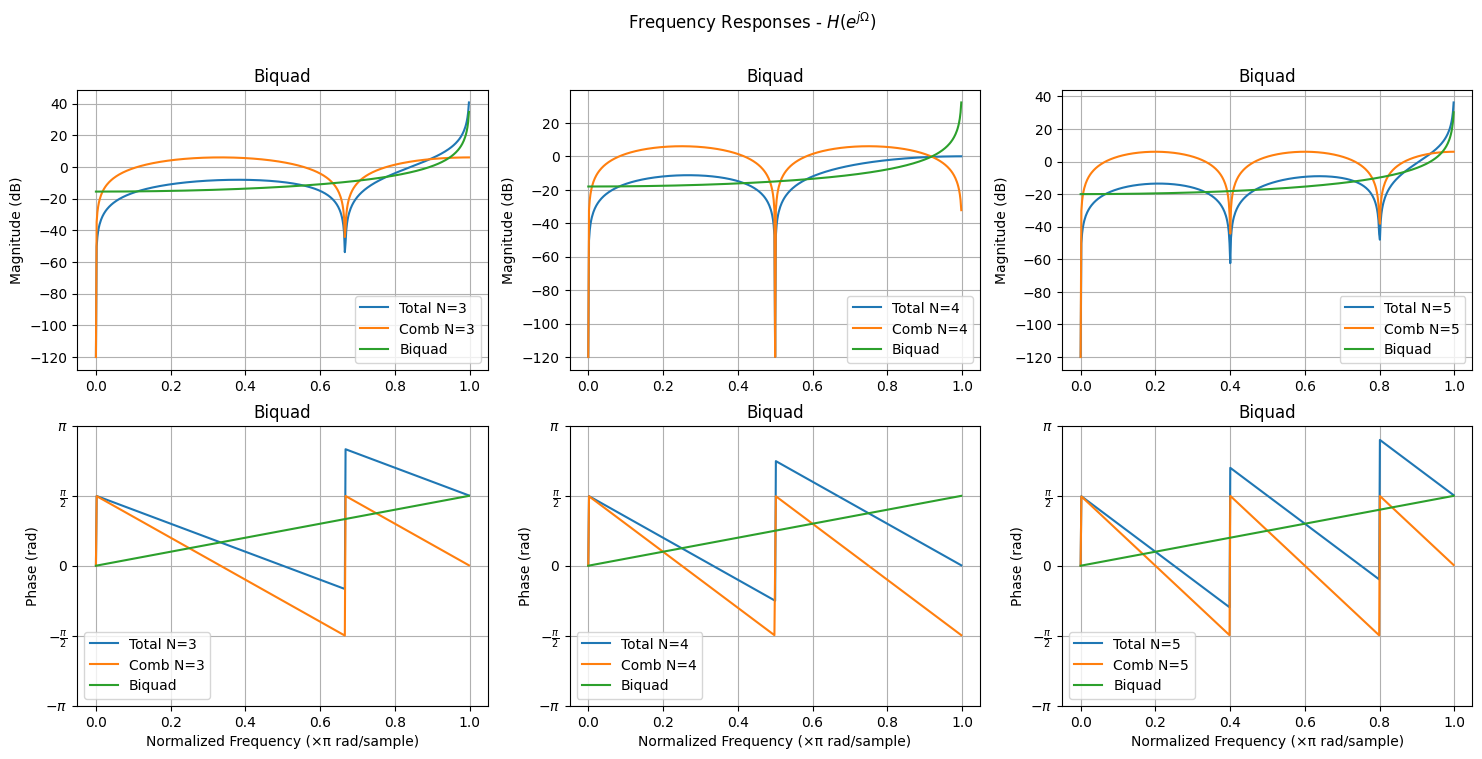

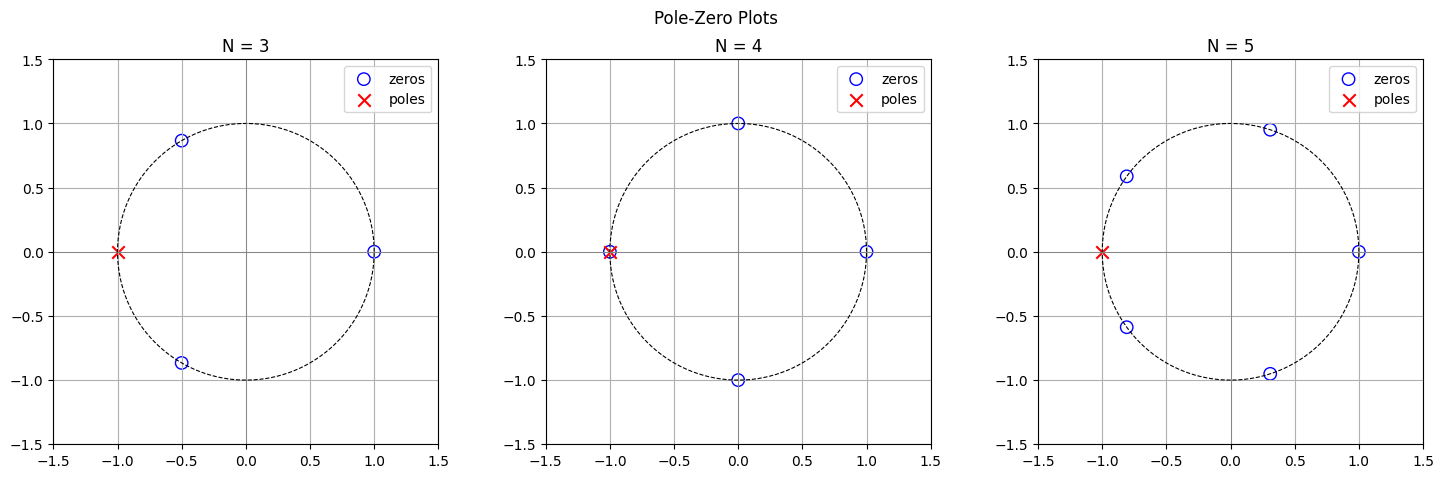

In [5]:
# Plot for N = 3, 4, 5
fs = 2

N_list = [3, 4, 5]
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 8))
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
for idx, N_val in enumerate(N_list):
    a_comb = [1]
    b_comb = [1] + [0] * (N_val - 1) + [-1]

    a_bq = [1, 1]
    b_bq = [1 / N_val]

    a_total = np.convolve(a_comb, a_bq)
    b_total = np.convolve(b_comb, b_bq)

    ax_mag = axes1[0, idx]
    ax_phase = axes1[1, idx]
    mag_and_phase(
        b=b_total, a=a_total, ax_mag=ax_mag, ax_phase=ax_phase, label=f"Total N={N_val}"
    )
    mag_and_phase(
        b=b_comb, a=a_comb, ax_mag=ax_mag, ax_phase=ax_phase, label=f"Comb N={N_val}"
    )
    mag_and_phase(b=b_bq, a=a_bq, ax_mag=ax_mag, ax_phase=ax_phase, label=f"Biquad")

    # Poles and Zeros
    ax = axes2[idx]
    a_total = np.convolve(a_comb, a_bq)
    b_total = np.convolve(b_comb, b_bq)
    zplane(b_total, a_total, ax=ax, title=f"N = {N_val}")

fig1.suptitle("Frequency Responses - $H(e^{j\Omega})$")
fig2.suptitle("Pole-Zero Plots")

plt.show()

## Ejercicio 3 - Filtro Diferenciador

In [6]:
H3 = (1 - z**-2) / 2

markdown_msg = f"""
### Expresión simbólica
A partir de la definición de diferenciador discreto:
$$y(n) = \\frac{1}{2}(x(n) - x(n-2))$$
Se obtiene la función de transferencia:
$$H(z) = {sp.latex(H3)}$$
### Coeficientes
Se considera $a_0 = 1$ como convención.
- Numerador:
    - $b_0 = 1/2$
    - $b_1 = 0$
    - $b_2 = -1/2$ 
- Denominador:
    - $a_0 = 1$
    - $a_1 = 0$
    - $a_2 = 0$
    
Se aprecia que el filtro es una muy buena aproximación a las funciones diff() de numpy y scipy.fftpack.
Hay un leve desfase/retardo en la salida del filtro, pero es mínimo.
"""
display(Markdown(markdown_msg))


### Expresión simbólica
A partir de la definición de diferenciador discreto:
$$y(n) = \frac12(x(n) - x(n-2))$$
Se obtiene la función de transferencia:
$$H(z) = \frac{1}{2} - \frac{1}{2 z^{2}}$$
### Coeficientes
Se considera $a_0 = 1$ como convención.
- Numerador:
    - $b_0 = 1/2$
    - $b_1 = 0$
    - $b_2 = -1/2$ 
- Denominador:
    - $a_0 = 1$
    - $a_1 = 0$
    - $a_2 = 0$
    
Se aprecia que el filtro es una muy buena aproximación a las funciones diff() de numpy y scipy.fftpack.
Hay un leve desfase/retardo en la salida del filtro, pero es mínimo.


Zeros: [-1.  1.]
Poles: []


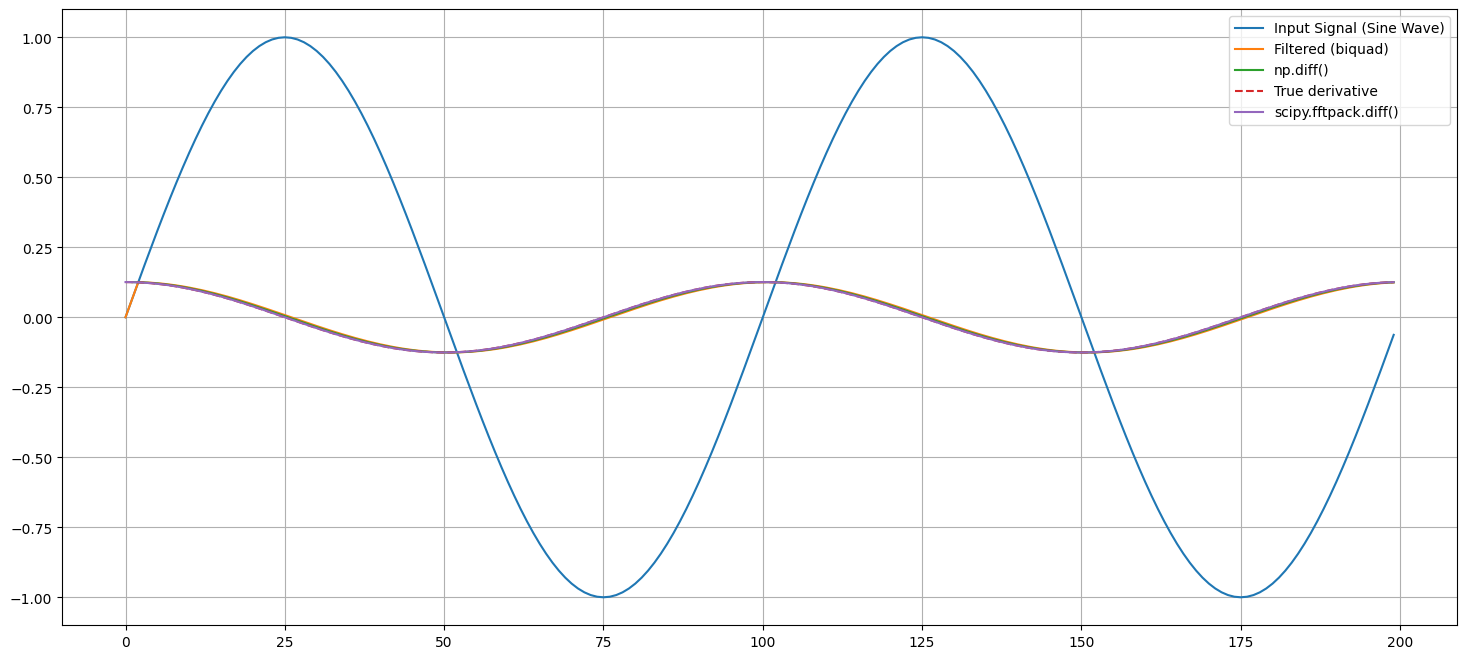

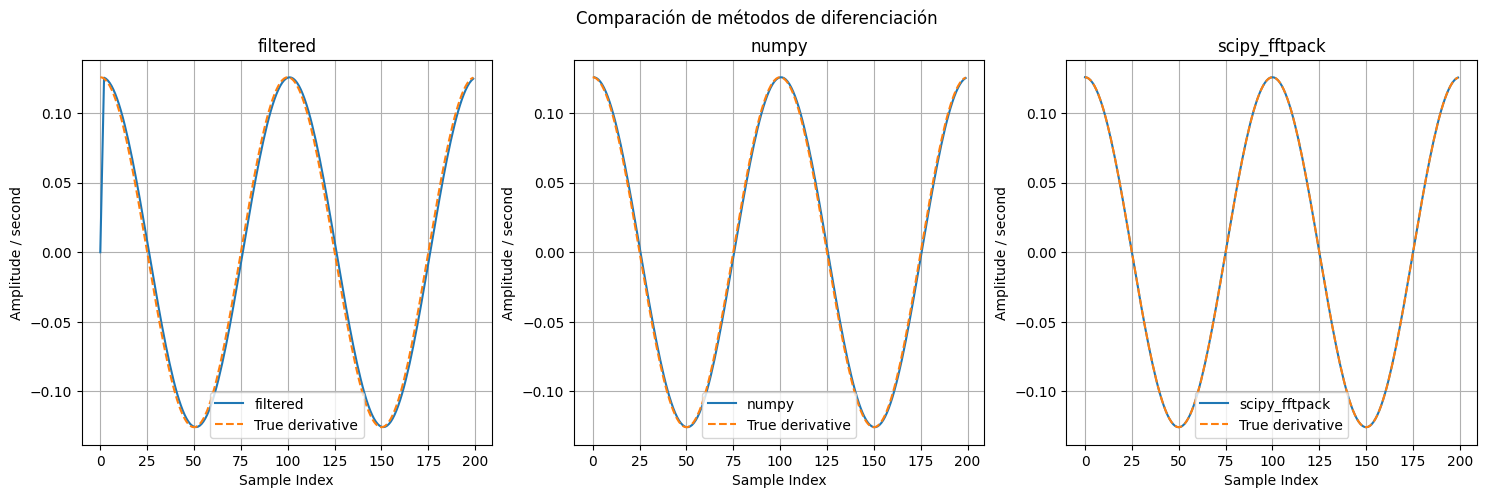

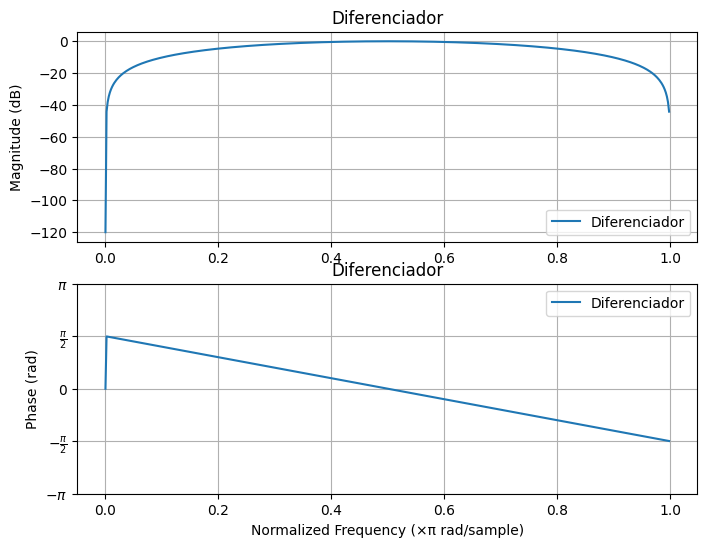

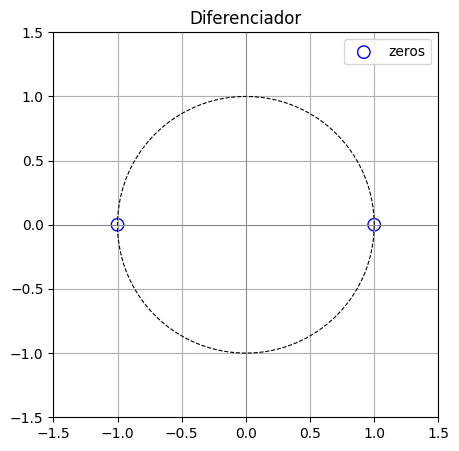

In [7]:
fs = 2
f = 0.02
N = 200
n = np.arange(N)
t = n / fs
dt = 1.0 / fs

discrete_sine = np.sin(2 * np.pi * f * t)

b3 = [1 / 2, 0, -1 / 2]
a3 = [1]

diff_filtered = sig.lfilter(b3, a3, discrete_sine) / dt

# use diff() but scale by 1/dt to get derivative units (samples -> seconds)
diff_numpy = np.diff(discrete_sine) / dt
diff_numpy = np.concatenate(
    ([np.nan], diff_numpy)
)  # derivative corresponds to index 1..N-1

# If you prefer FFT-based scipy.fftpack.diff, do NOT pass period=1/f (that caused wrong scaling).
# Use np.diff/dt unless you need spectral differentiation.
diff_scipy_fftpack = fftpack.diff(discrete_sine, period=N * dt)

# true continuous derivative: d/dt sin(2π f t) = 2π f cos(2π f t)
true_derivative = 2 * np.pi * f * np.cos(2 * np.pi * f * t)

plt.figure(figsize=(18, 8))
plt.plot(n, discrete_sine, label="Input Signal (Sine Wave)")
plt.plot(n, diff_filtered, label="Filtered (biquad)")
plt.plot(n, diff_numpy, label="np.diff()")
plt.plot(n, true_derivative, label="True derivative", linestyle="--")
plt.plot(n, diff_scipy_fftpack, label="scipy.fftpack.diff()")
plt.legend()
plt.grid()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, method in enumerate(["filtered", "numpy", "scipy_fftpack"]):
    axes[idx].plot(n, eval(f"diff_{method.lower().replace(' ', '_')}"), label=method)
    axes[idx].plot(n, true_derivative, label="True derivative", linestyle="--")
    axes[idx].set_title(method)
    axes[idx].set_xlabel("Sample Index")
    axes[idx].set_ylabel("Amplitude / second")
    axes[idx].legend()
    axes[idx].grid()

fig.suptitle("Comparación de métodos de diferenciación")

mag_and_phase(b=b3, a=a3, ax_mag=None, ax_phase=None, label=f"Diferenciador")
zplane(b3, a3, ax=None, title=f"Diferenciador")

plt.show()

## Ejercicio 4 - DC Blocker

In [8]:
beta = sp.symbols("beta", real=True, positive=True)
H4 = (1 - z**-1) / (1 - beta * z**-1)

H4_mag = sp.Abs(H4.subs(z, sp.exp(sp.I * sp.symbols("Omega", real=True))))

beta = sp.symbols("beta", real=True, positive=True)
H4 = (1 - z**-1) / (1 - beta * z**-1)

Omega = sp.symbols("Omega", real=True)
H4_sub = H4.subs(z, sp.exp(sp.I * Omega))
H4_mag_simpl = sp.simplify(sp.Abs(H4_sub))

# closed-form
expr_manual = 2 * sp.sin(Omega / 2) / sp.sqrt(1 + beta**2 - 2 * beta * sp.cos(Omega))

H4_mag_beta09 = sp.simplify(H4_mag_simpl.subs(beta, sp.N(0.9)))

# Verificación numérica de equivalencia
f_num = sp.lambdify(
    Omega, sp.N(expr_manual.subs(beta, 0.9) - H4_mag_simpl.subs(beta, 0.9)), "numpy"
)
omegas = np.linspace(0, np.pi, 201)
res_vals = f_num(omegas)
max_abs = np.max(np.abs(res_vals))

# Beta para pi/10 usando solve con la expresión-cerrada obtendida a mano
H4_mag_pi10 = expr_manual.subs(Omega, np.pi / 10)
H4_mag_pi = expr_manual.subs(Omega, np.pi)
beta_sol = sp.solve(sp.Eq(H4_mag_pi10, 0.7079 * H4_mag_pi), beta)
beta_sol = [sol.evalf() for sol in beta_sol if sol.is_real and sol > 0 and sol < 1]
beta_sol_by_hand = beta_sol[0] if beta_sol else None

# Beta para pi/10 usando nsolve con la expresión simbólica
eq = H4_mag_simpl.subs(Omega, sp.pi / 10) - 0.7079 * H4_mag_simpl.subs(Omega, sp.pi)
beta_sol = None
for guess in (0.1, 0.3, 0.5, 0.7, 0.9):
    try:
        sol = sp.nsolve(eq, beta, guess, tol=1e-14, maxsteps=100)
        solf = float(sol)
        if 0 < solf < 1:
            beta_sol = solf
            break
    except Exception:
        continue

markdown_msg = f"""
### Expresión simbólica
Se obtiene la función de transferencia:
$$H(z) = {sp.latex(H4)}$$

La magnitud es:
$$|H(e^{{j\\Omega}})| = {sp.latex(H4_mag_simpl)}$$

Que es equivalente a la expresión obtenida a mano:
$$|H(e^{{j\\Omega}})| = {sp.latex(sp.simplify(expr_manual))}$$

Reemplazando $\\beta = 0.9$:
$$|H(e^{{j\\Omega}})| = {sp.latex(H4_mag_beta09)}$$

### Verificación numérica
Se realiza una verificación numérica de la equivalencia entre las expresiones.
El máximo valor absoluto de la diferencia en el rango $\\Omega \\in [0, \\pi]$ es: {max_abs}, lo que indica que las expresiones son equivalentes dentro de una tolerancia de $1E^{{-12}}$.

Luego se evalua la magnitud en $\\Omega = 0$ que sería DC para verificar que a la salida hay señal:

$$|H(e^{{j0}})| = {H4_mag_simpl.subs(Omega, 0)}$$

### Obtención de coeficientes \\beta para un atenuación deseada
Se hace uso de la siguiente expresión:

$$20 \\log_{{10}}(x) = -3[dB] \; \\rightarrow \; x = 10^{{-3/20}} \\approx 0.7079$$

Luego, se iguala la expresión de magnitudes en $\\Omega = \\pi$ a $0.7079$ menos que la magnitud en $\\Omega = \\frac{{\\pi}}{{10}}$
y se despeja $\\beta$ para $\\Omega = \\frac{{\\pi}}{{10}}$:

$$|H(e^{{j\\frac{{\\pi}}{{10}}}})| = 0.7079 \, |H(e^{{j\\pi}})|$$

Solución obtenida con la expresión-cerrada: $\\beta = {beta_sol_by_hand}$

Solución obtenida con nsolve: $\\beta = {beta_sol}$

### Coeficientes
Se considera $a_0 = 1$ como convención.
- Numerador:
    - $b_0 = 1$
    - $b_1 = -1$
    - $b_2 = 0$ 
- Denominador:
    - $a_0 = 1$
    - $a_1 = \\beta$
    - $a_2 = 0$
"""
display(Markdown(markdown_msg))


### Expresión simbólica
Se obtiene la función de transferencia:
$$H(z) = \frac{1 - \frac{1}{z}}{- \frac{\beta}{z} + 1}$$

La magnitud es:
$$|H(e^{j\Omega})| = \frac{\sqrt{2 - 2 \cos{\left(\Omega \right)}}}{\sqrt{\beta^{2} - \beta e^{i \Omega} - \beta e^{- i \Omega} + 1}}$$

Que es equivalente a la expresión obtenida a mano:
$$|H(e^{j\Omega})| = \frac{2 \sin{\left(\frac{\Omega}{2} \right)}}{\sqrt{\beta^{2} - 2 \beta \cos{\left(\Omega \right)} + 1}}$$

Reemplazando $\beta = 0.9$:
$$|H(e^{j\Omega})| = \frac{0.743294146247166 \sqrt{2 - 2 \cos{\left(\Omega \right)}}}{\sqrt{1 - 0.994475138121547 \cos{\left(\Omega \right)}}}$$

### Verificación numérica
Se realiza una verificación numérica de la equivalencia entre las expresiones.
El máximo valor absoluto de la diferencia en el rango $\Omega \in [0, \pi]$ es: 4.107825191113079e-14, lo que indica que las expresiones son equivalentes dentro de una tolerancia de $1E^{-12}$.

Luego se evalua la magnitud en $\Omega = 0$ que sería DC para verificar que a la salida hay señal:

$$|H(e^{j0})| = 0$$

### Obtención de coeficientes \beta para un atenuación deseada
Se hace uso de la siguiente expresión:

$$20 \log_{10}(x) = -3[dB] \; \rightarrow \; x = 10^{-3/20} \approx 0.7079$$

Luego, se iguala la expresión de magnitudes en $\Omega = \pi$ a $0.7079$ menos que la magnitud en $\Omega = \frac{\pi}{10}$
y se despeja $\beta$ para $\Omega = \frac{\pi}{10}$:

$$|H(e^{j\frac{\pi}{10}})| = 0.7079 \, |H(e^{j\pi})|$$

Solución obtenida con la expresión-cerrada: $\beta = 0.727072026994584$

Solución obtenida con nsolve: $\beta = 0.7270720269945841$

### Coeficientes
Se considera $a_0 = 1$ como convención.
- Numerador:
    - $b_0 = 1$
    - $b_1 = -1$
    - $b_2 = 0$ 
- Denominador:
    - $a_0 = 1$
    - $a_1 = \beta$
    - $a_2 = 0$


Zeros: [1. 0.]
Poles: [-0.9  0. ]
Zeros: [1. 0.]
Poles: [-0.72707203  0.        ]


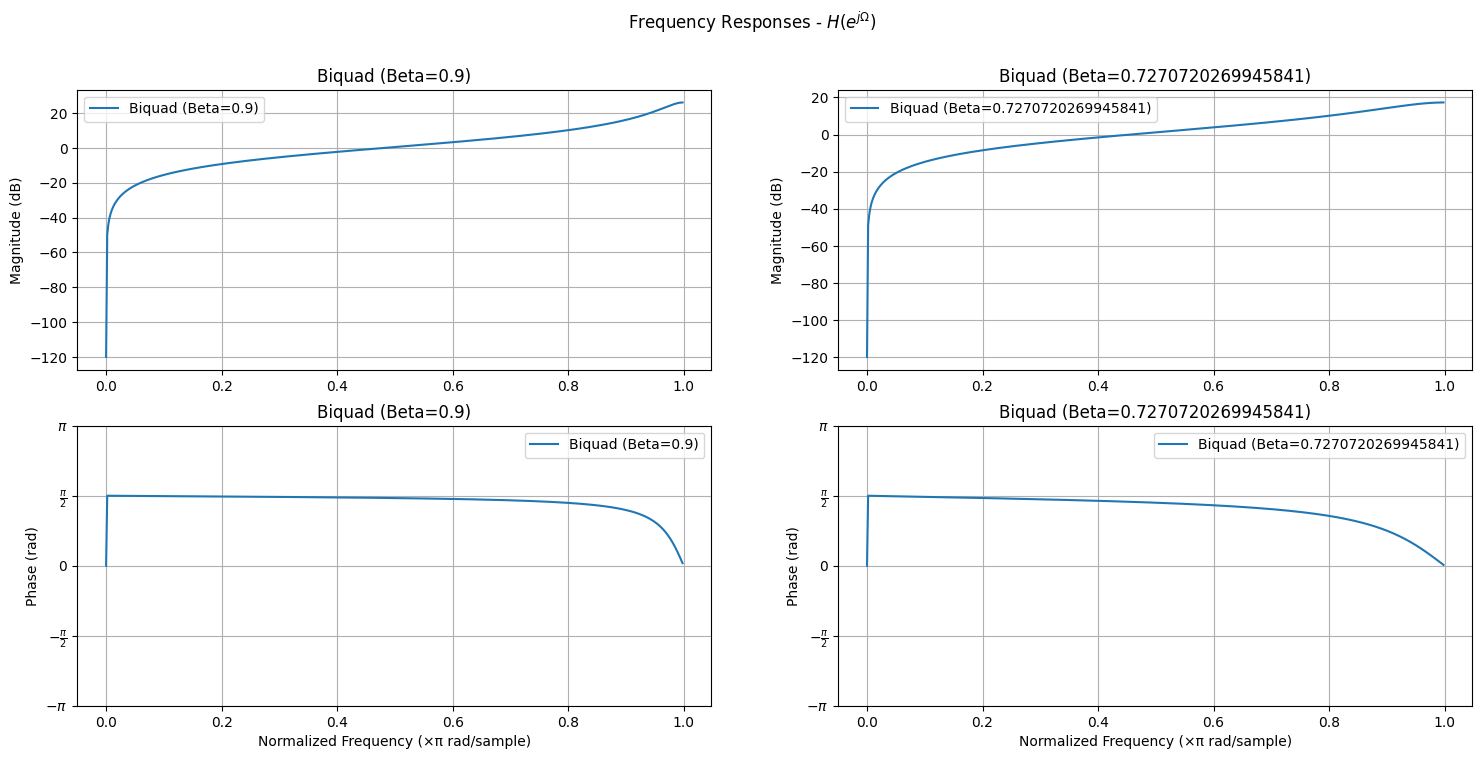

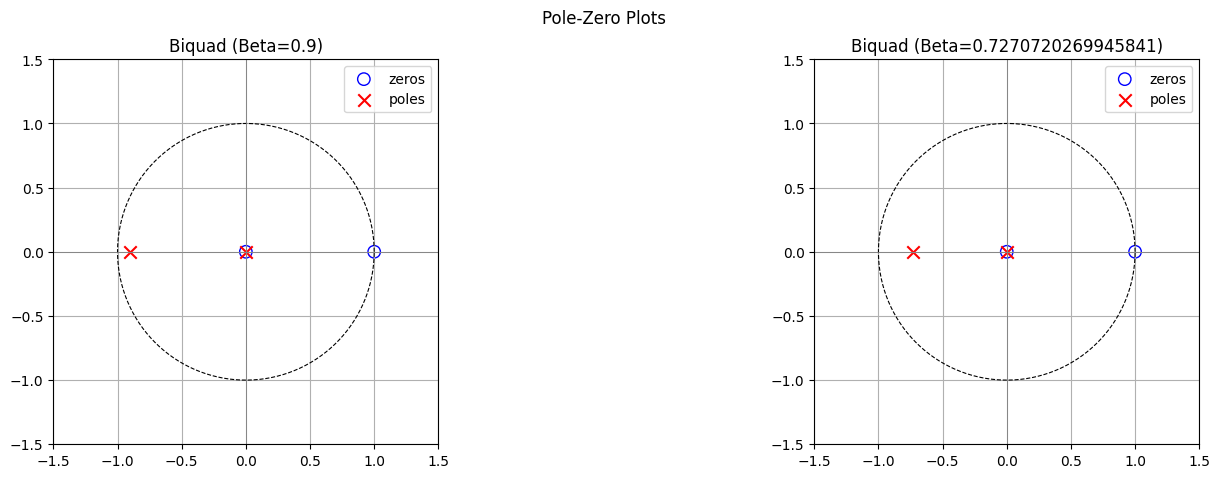

In [9]:
fs = 2

beta_list = [0.9, beta_sol]
fig1, axes1 = plt.subplots(2, 2, figsize=(18, 8))
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 5))
for idx, beta in enumerate(beta_list):
    a_bq = [1, beta, 0]
    b_bq = [1, -1, 0]

    ax_mag = axes1[0, idx]
    ax_phase = axes1[1, idx]
    mag_and_phase(
        b=b_bq, a=a_bq, ax_mag=ax_mag, ax_phase=ax_phase, label=f"Biquad (Beta={beta})"
    )

    # Poles and Zeros
    ax = axes2[idx]
    zplane(b_bq, a_bq, ax=ax, title=f"Biquad (Beta={beta})")

fig1.suptitle("Frequency Responses - $H(e^{j\Omega})$")
fig2.suptitle("Pole-Zero Plots")

plt.show()

## Ejercicio 5 - Comb Filter


### Expresión simbólica
Se obtiene la función de transferencia:
$$H(z) = - c_{1} z^{- N} + 1$$

Reemplazando $N=8$ y $c_1=-1$:
$$H(z) = 1 + \frac{1}{z^{8}}$$

La magnitud es:
$$|H(e^{j\Omega})| = \sqrt{2 \cos{\left(8 \Omega \right)} + 2}$$

Que es equivalente a la expresión obtenida a mano:
$$|H(e^{j\Omega})| = 2 \left|{\cos{\left(4 \Omega \right)}}\right|$$

### Verificación numérica
Se realiza una verificación numérica de la equivalencia entre las expresiones.
El máximo valor absoluto de la diferencia en el rango $\Omega \in [0, \pi]$ es: 7.327471962526033e-15, lo que indica que las expresiones son equivalentes dentro de una tolerancia de $1E^{-12}$.

### Obtención de los peaks y nulls
- Peaks (máximos): 
$$\Omega = \frac{(2k+1)\pi}{8} \, , k = 0, 1, 2, ...$$
- Nulls (mínimos): 
$$\Omega = \frac{k\pi}{4} \, , k = 0, 1, 2, ...$$

Si se utiliza una $f_s = 8 \, kHz$ los peaks y nulls en Hz serían:
- Peaks (máximos):
    - 0 Hz
    - 1000 Hz
    - 2000 Hz
    - 3000 Hz
    - 4000 Hz
- Nulls (mínimos):
    - 500 Hz
    - 1500 Hz
    - 2500 Hz
    - 3500 Hz
    
Se aprecia en el gráfico de magnitud que los peaks y nulls coinciden con las frecuencias calculadas.

### Coeficientes
Se considera $a_0 = 1$ como convención.
- Numerador:
    - $b_0 = 1$
    - $b_8 = 1$ 
- Denominador:
    - $a_0 = 1$


Zeros: [-0.92387953+0.38268343j -0.92387953-0.38268343j -0.38268343+0.92387953j
 -0.38268343-0.92387953j  0.38268343+0.92387953j  0.38268343-0.92387953j
  0.92387953+0.38268343j  0.92387953-0.38268343j]
Poles: []


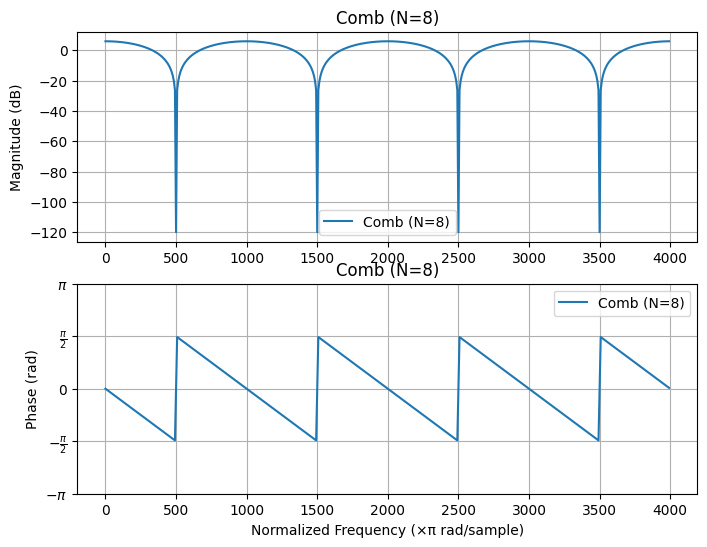

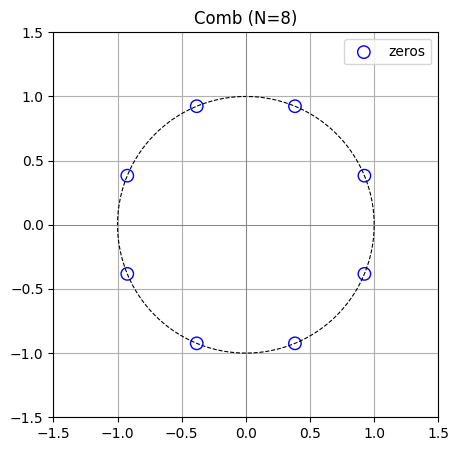

In [10]:
N, c = sp.symbols("N c_1", real=True, positive=True)
H5 = 1 - c * z**-N
H5_subs = H5.subs(N, 8).subs(c, -1)
H5_mag = sp.Abs(
    H5_subs.subs(z, sp.exp(sp.I * sp.symbols("Omega", real=True)))
).simplify()

# closed-form
expr_manual = 2 * sp.Abs(sp.cos(Omega * 4))

# Verificación numérica de equivalencia
f_num = sp.lambdify(Omega, sp.N(expr_manual - H5_mag), "numpy")
omegas = np.linspace(0, np.pi, 201)
res_vals = f_num(omegas)
max_abs = np.max(np.abs(res_vals))

markdown_msg = f"""
### Expresión simbólica
Se obtiene la función de transferencia:
$$H(z) = {sp.latex(H5)}$$

Reemplazando $N=8$ y $c_1=-1$:
$$H(z) = {sp.latex(H5_subs)}$$

La magnitud es:
$$|H(e^{{j\\Omega}})| = {sp.latex(H5_mag)}$$

Que es equivalente a la expresión obtenida a mano:
$$|H(e^{{j\\Omega}})| = {sp.latex(sp.simplify(expr_manual))}$$

### Verificación numérica
Se realiza una verificación numérica de la equivalencia entre las expresiones.
El máximo valor absoluto de la diferencia en el rango $\\Omega \\in [0, \\pi]$ es: {max_abs}, lo que indica que las expresiones son equivalentes dentro de una tolerancia de $1E^{{-12}}$.

### Obtención de los peaks y nulls
- Peaks (máximos): 
$$\\Omega = \\frac{{(2k+1)\\pi}}{{8}} \, , k = 0, 1, 2, ...$$
- Nulls (mínimos): 
$$\\Omega = \\frac{{k\\pi}}{{4}} \, , k = 0, 1, 2, ...$$

Si se utiliza una $f_s = 8 \, kHz$ los peaks y nulls en Hz serían:
- Peaks (máximos):
    - 0 Hz
    - 1000 Hz
    - 2000 Hz
    - 3000 Hz
    - 4000 Hz
- Nulls (mínimos):
    - 500 Hz
    - 1500 Hz
    - 2500 Hz
    - 3500 Hz
    
Se aprecia en el gráfico de magnitud que los peaks y nulls coinciden con las frecuencias calculadas.

### Coeficientes
Se considera $a_0 = 1$ como convención.
- Numerador:
    - $b_0 = 1$
    - $b_8 = 1$ 
- Denominador:
    - $a_0 = 1$
"""
display(Markdown(markdown_msg))

a = [1]
N = 8
b = [1] + [0] * (N - 1) + [1]
mag_and_phase(b=b, a=a, ax_mag=None, ax_phase=None, fs=8e3, label=f"Comb (N={N})")
zplane(b, a, ax=None, title=f"Comb (N={N})")
plt.show()

# Extra - AllPass con Biquad a partir de la Transformada Bilineal


### Expresión simbólica
Se obtiene la función de transferencia:
$$H(s) = \frac{- \sigma + s}{\sigma + s}$$

Aplicando el kernel de la Transformada Bilineal:
$$H(z) = \frac{- \sigma z - \sigma + k z - k}{\sigma z + \sigma + k z - k}$$

El numerador y denominador pueden ser factorizados y normalizados:
$$H(z) = \frac{- \sigma z - \sigma + k z - k}{\sigma z + \sigma + k z - k} = \frac{\frac{z \left(- \sigma + k\right)}{\sigma + k} - 1}{z + \frac{\sigma - k}{\sigma + k}}$$

### Coeficientes
Se considera $a_0 = 1$ como convención.
- $k = 2 \, f_s$
- $\sigma = 0.5$

- Numerador:
    - $b_0 = 0.7777777777777777$
    - $b_1 = -1.0$
- Denominador:
    - $a_0 = 1.0$
    - $a_1 = -0.7777777777777777$
    
Un hecho a destacar es que los polos y ceros son el inverso uno del otro respecto del círculo unitario, lo que confirma que es un filtro AllPass.
Se puede modificar el valor de $\sigma$ y $f_s$ para observar diferentes respuestas en frecuencia y ubicaciones de polos y ceros.


Zeros: [1.28571429]
Poles: [0.77777778]


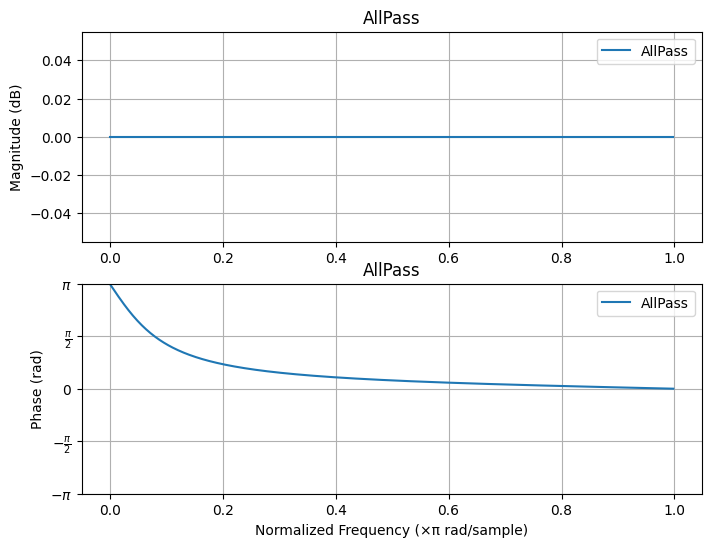

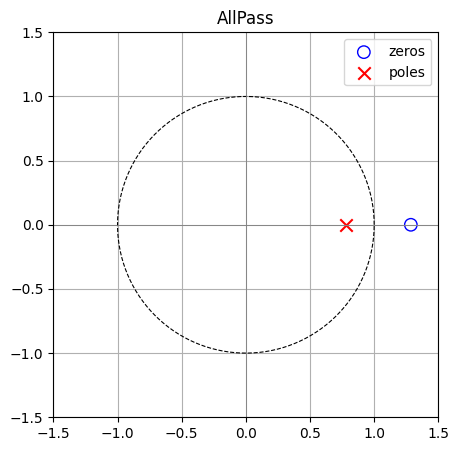

In [11]:
s, sigma, k = sp.symbols("s \sigma k", complex=True)
H_s = (s - sigma) / (s + sigma)  # Transformada AllPass analógica
kernel = k * (z - 1) / (z + 1)  # Kernel de la Transformada Bilineal

fs = 2
sigma_val = 0.5
H_z = H_s.subs(s, kernel).expand().simplify()

H_z_t = sp.together(H_z)
num_sym, den_sym = H_z_t.as_numer_denom()
num_sym = sp.simplify(sp.factor(num_sym))
den_sym = sp.simplify(sp.factor(den_sym))

num_poly = sp.Poly(sp.expand(num_sym), z)
den_poly = sp.Poly(sp.expand(den_sym), z)
lc_den = den_poly.LC()
num_poly_monic = sp.Poly(sp.expand(num_poly.as_expr() / lc_den), z)
den_poly_monic = sp.Poly(sp.expand(den_poly.as_expr() / lc_den), z)

# Lista de coeficientes (potencias descendentes de z)
b_coeffs_desc_z = num_poly_monic.all_coeffs()
a_coeffs_desc_z = den_poly_monic.all_coeffs()

a = [c.subs(sigma, sigma_val).subs(k, 2 * fs) for c in den_poly_monic.all_coeffs()]
b = [c.subs(sigma, sigma_val).subs(k, 2 * fs) for c in num_poly_monic.all_coeffs()]
a = [float(c.evalf()) for c in a]
b = [float(c.evalf()) for c in b]

markdown_msg = f"""
### Expresión simbólica
Se obtiene la función de transferencia:
$$H(s) = {sp.latex(H_s)}$$

Aplicando el kernel de la Transformada Bilineal:
$$H(z) = {sp.latex(H_z)}$$

El numerador y denominador pueden ser factorizados y normalizados:
$$H(z) = {sp.latex(H_z_t)} = \\frac{{{sp.latex(num_poly_monic.as_expr())}}}{{{sp.latex(den_poly_monic.as_expr())}}}$$

### Coeficientes
Se considera $a_0 = 1$ como convención.
- $k = 2 \, f_s$
- $\\sigma = {sigma_val}$

- Numerador:
    - $b_0 = {b[0]}$
    - $b_1 = {b[1]}$
- Denominador:
    - $a_0 = {a[0]}$
    - $a_1 = {a[1]}$
    
Un hecho a destacar es que los polos y ceros son el inverso uno del otro respecto del círculo unitario, lo que confirma que es un filtro AllPass.
Se puede modificar el valor de $\\sigma$ y $f_s$ para observar diferentes respuestas en frecuencia y ubicaciones de polos y ceros.
"""
display(Markdown(markdown_msg))

mag_and_phase(b=b, a=a, ax_mag=None, ax_phase=None, label=f"AllPass")
zplane(b, a, ax=None, title=f"AllPass")
plt.show()